<a href="https://colab.research.google.com/github/xuyanke711/pairs-trading-start-arb/blob/main/pairs_trading_statistical_arbitrage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cointegration-Based Pairs Trading Strategy
## Objective
This project develops and evaluates a statistical arbitrage strategy on U.S. financial equities

The workflow:
1. Screen candidate pairs using return correlation and cointegration.
2. Estimate the hedge ratio using training data only.
3. Construct an out-of-sample spread and z-score.
4. Generate mean-reversion trading signals.
5. Backtest the strategy with transaction costs.
6. Evaluate robustness using sensitivity analysis.

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm

from itertools import combinations
from statsmodels.tsa.stattools import coint

Markdown
## 1. Data Collection
We download daily adjusted closing prices for a universe of U.S. financial equities from Yahoo Finance.

In [119]:
bank_tickers=["JPM","BAC","C","WFC","GS","MS","USB","PNC","STT","SCHW","COF"]
bank_data=yf.download(bank_tickers,start="2021-01-01",end="2026-09-28",auto_adjust=True)
bank_prices=bank_data["Close"].dropna()
print(bank_prices.head())
print(bank_prices.shape)

[*********************100%***********************]  11 of 11 completed

Ticker            BAC          C         COF          GS         JPM  \
Date                                                                   
2021-01-04  26.193619  49.556885   88.406273  231.925079  109.000526   
2021-01-05  26.394230  50.842381   90.484505  237.114929  109.593636   
2021-01-06  28.042780  53.767670   97.026428  249.910126  114.739693   
2021-01-07  28.662079  54.402157  100.053413  255.248856  118.507645   
2021-01-08  28.374237  53.866547   99.899811  253.874802  118.638489   

Ticker             MS         PNC       SCHW        STT        USB        WFC  
Date                                                                           
2021-01-04  57.307854  121.654465  48.942150  60.912025  36.192505  26.040951  
2021-01-05  58.280739  121.010101  48.951424  61.274525  36.310223  26.768700  
2021-01-06  61.794861  127.657646  53.255661  65.447731  38.460415  28.662588  
2021-01-07  62.851620  129.688644  54.786263  65.532043  39.229477  29.311415  
2021-01-08  63.

## 2. Train-Test Split
The dataset is divided into a training period and a testing period.

The training period is used for pair selection and parameter estimation, while the testing period is reserved for out-of-sample evaluation.

In [120]:
split_date="2025-01-01"
train_prices=bank_prices[bank_prices.index<split_date]
test_prices=bank_prices[bank_prices.index>=split_date]

print("Training data shape:",train_prices.shape)
print("Testing data shape:",test_prices.shape)

print("Training period:",train_prices.index.min(),"to",train_prices.index.max())
print("Testing period:",test_prices.index.min(),"to",test_prices.index.max())


Training data shape: (1005, 11)
Testing data shape: (434, 11)
Training period: 2021-01-04 00:00:00 to 2024-12-31 00:00:00
Testing period: 2025-01-02 00:00:00 to 2026-09-25 00:00:00


## 3. Pair Screening
Candidate pairs are screened using two criteria:

1. Daily return correlation, which measures short-term co-movement.
2. The Engle-Granger cointegration test, which tests for a stable long-run relationship between price series.

All screening is performed using training data only to avoid look-ahead bias.

In [121]:
train_returns=train_prices.pct_change().dropna()
train_results=[]
for stock1,stock2 in combinations(bank_tickers,2):
  corr=train_returns[stock1].corr(train_returns[stock2])
  score,pvalue,_=coint(train_prices[stock1],train_prices[stock2])
  train_results.append({"Stock1":stock1,"Stock2":stock2,"Correlation":corr,"Cointegration p-value":pvalue})
  train_results_df=pd.DataFrame(train_results)
  train_results_df=train_results_df.sort_values(by="Cointegration p-value")
print(train_results_df.head(15))

   Stock1 Stock2  Correlation  Cointegration p-value
15    BAC    PNC     0.806673               0.040570
26      C    COF     0.674822               0.076781
27    WFC     GS     0.715412               0.086970
34     GS     MS     0.818970               0.176942
54   SCHW    COF     0.495443               0.178549
42     MS    STT     0.655317               0.194316
28    WFC     MS     0.681206               0.198538
53    STT    COF     0.630523               0.209187
10    BAC      C     0.809792               0.242313
16    BAC    STT     0.720867               0.247616
18    BAC    COF     0.708851               0.277780
45    USB    PNC     0.798917               0.291096
49    PNC    STT     0.694553               0.311519
3     JPM     GS     0.763518               0.324224
47    USB   SCHW     0.580968               0.329313


## 4. Selected Pair:BAC-PNC
BAC-PNC is selected as the candidate pair because it has the lowest training-period cointegration p-value among the screened pairs and a relatively high return correlation.

Training-period statistics:
- Return correlation: approximately 0.807
- Cointegration p-value: approximately 0.041

In [122]:
X=sm.add_constant(train_prices["BAC"])
Y=train_prices["PNC"]
bac_pnc_model=sm.OLS(Y,X).fit()
alpha=bac_pnc_model.params["const"]
beta=bac_pnc_model.params["BAC"]
print("alpha=",alpha)
print("beta=",beta)

alpha= 6.521205613544244
beta= 4.107822354673766


The training-period relationship is estimated as:

PNC=alpha+beta*BAC+error

The estimated beta is the hedge ratio used to construct the spread.


## 5. Spread Construction
The spread is defined as the difference between the observed PNC price implied by the BAC-PNC regression relationship.

The training-period regression parameters are held fixed when constructing the test-period spread.

In [123]:
predicted_pnc_train=alpha+beta*train_prices["BAC"]
train_spread=train_prices["PNC"]-predicted_pnc_train
predicted_pnc_test=alpha+beta*test_prices["BAC"]
test_spread=test_prices["PNC"]-predicted_pnc_test
print(train_spread.head())
print(test_spread.head())

Date
2021-01-04    7.534526
2021-01-05    6.066088
2021-01-06    5.941682
2021-01-07    5.428711
2021-01-08    5.950423
dtype: float64
Date
2025-01-02   -1.212719
2025-01-03    0.727290
2025-01-06   -1.641796
2025-01-07   -5.101347
2025-01-08   -5.699837
dtype: float64


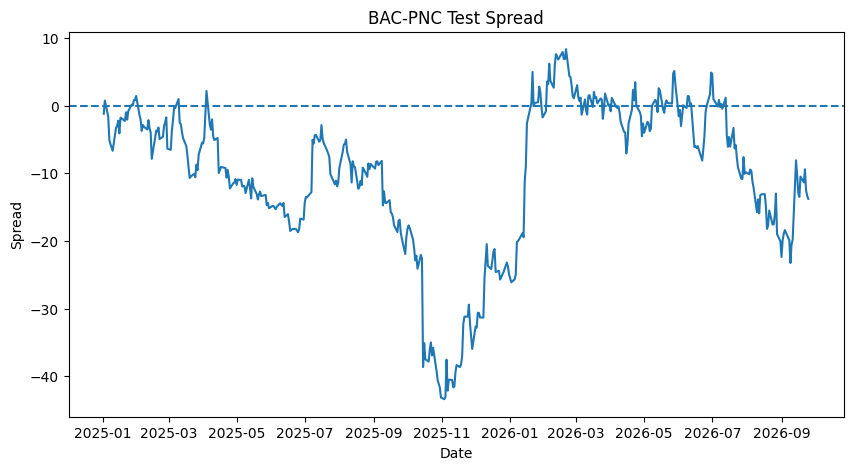

In [124]:
plt.figure(figsize=(10,5))
plt.plot(test_spread)
plt.axhline(0,linestyle="--")
plt.title("BAC-PNC Test Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.show()

## 6. Z-Score Standardisation
The spread is standardised using the mean and standard deviation estimated from the training period.

This allows the test-period spread to be expressed in units of standard deviations from its training-period mean.

In [125]:
train_spread_mean=train_spread.mean()
train_spread_std=train_spread.std()
test_zscore=(test_spread-train_spread_mean)/train_spread_std
print("Training spread mean =",train_spread_mean)
print("Training spread std =",train_spread_std)
print(test_zscore.head())

Training spread mean = -1.3303056831902533e-13
Training spread std = 6.5115239419852
Date
2025-01-02   -0.186242
2025-01-03    0.111693
2025-01-06   -0.252137
2025-01-07   -0.783434
2025-01-08   -0.875346
dtype: float64


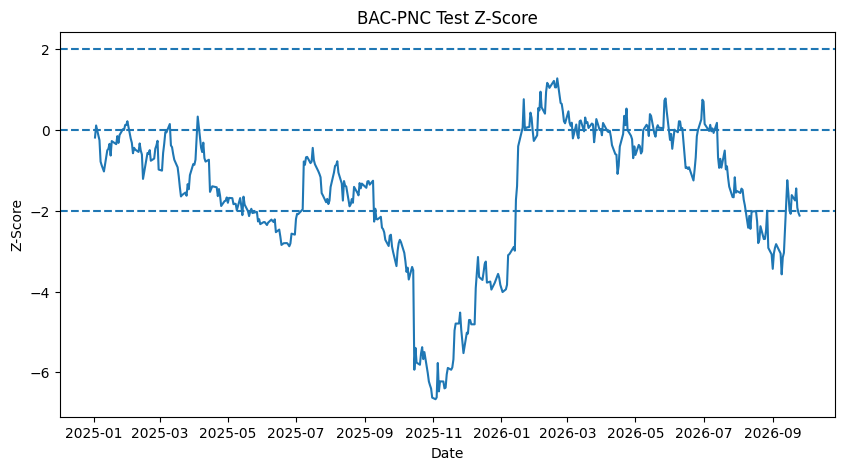

In [126]:
plt.figure(figsize=(10,5))
plt.plot(test_zscore)
plt.axhline(0,linestyle="--")
plt.axhline(2,linestyle="--")
plt.axhline(-2,linestyle="--")
plt.title("BAC-PNC Test Z-Score")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.show()

## 7. Trading Strategy
The strategy assumes mean reversion in the BAC-PNC spread.

Trading rules:
- Long the spread when z-score < -2
- Short the spread when z-score > 2
- Exit the position when |z-score| < 0.5

In [127]:
position=pd.Series(0,index=test_zscore.index)
current_position=0
for date in test_zscore.index:
  z=test_zscore.loc[date]
  if current_position==0:
    if z<-2:
      current_position=1
    elif z>2:
      current_position=-1
  elif current_position==1:
    if abs(z)<0.5:
      current_position=0
  elif current_position==-1:
    if abs(z)<0.5:
      current_position=0
  position.loc[date]=current_position
print(position.value_counts())

0    268
1    166
Name: count, dtype: int64


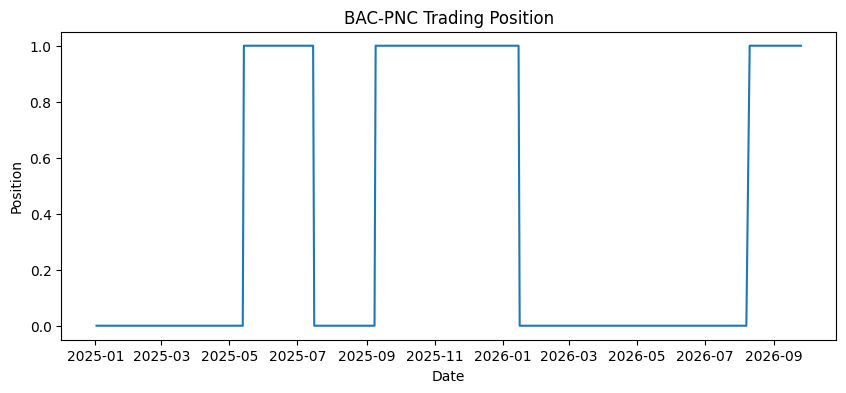

In [128]:
plt.figure(figsize=(10,4))
plt.plot(position)
plt.title("BAC-PNC Trading Position")
plt.xlabel("Date")
plt.ylabel("Position")
plt.show()

## 8. Out-of-Sample Backtest
Daily strategy P&L is calculated from changes in the BAC-PNC spread.

The position is shifted by one trading day so that today's P&L is based on yesterday's trading signal, reducing look-ahead bias.

In [129]:
spread_change=test_spread.diff()
strategy_pnl=position.shift(1)*spread_change
strategy_pnl=strategy_pnl.dropna()
print(strategy_pnl.head())
print("Total gross P&L =",strategy_pnl.sum())

Date
2025-01-03    0.0
2025-01-06   -0.0
2025-01-07   -0.0
2025-01-08   -0.0
2025-01-10   -0.0
dtype: float64
Total gross P&L = 24.944176585408314


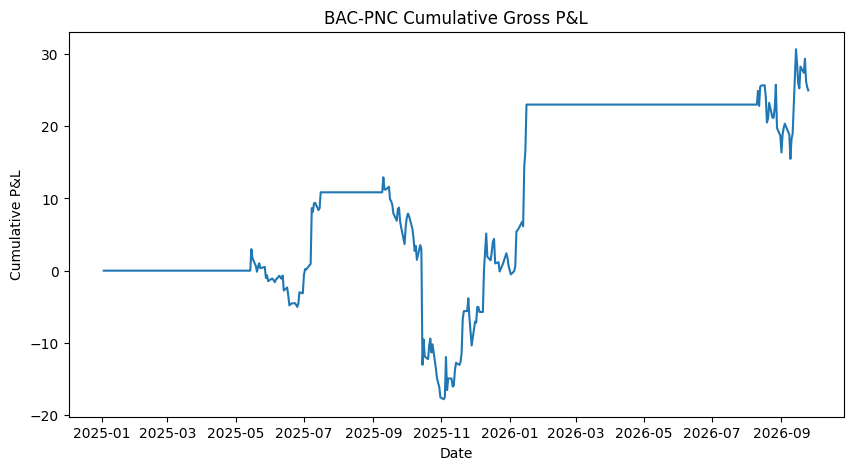

In [130]:
cumulative_pnl=strategy_pnl.cumsum()
plt.figure(figsize=(10,5))
plt.plot(cumulative_pnl)
plt.title("BAC-PNC Cumulative Gross P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L")
plt.show()

## 9. Transaction Costs
A transaction cost of 5 basis points(0.05%) is applied whenever the trading position changes.

Transaction costs are propositional to the gross notional exposure of pair.

In [131]:
gross_exposure=test_prices["PNC"]+beta*test_prices["BAC"]
position_change=position.diff().abs().fillna(0)
cost_rate=0.0005
transaction_cost=position_change*gross_exposure*cost_rate
net_pnl=strategy_pnl-transaction_cost.reindex(strategy_pnl.index).fillna(0)
print("Total net P&L =",net_pnl.sum())

Total net P&L = 23.913311341692236


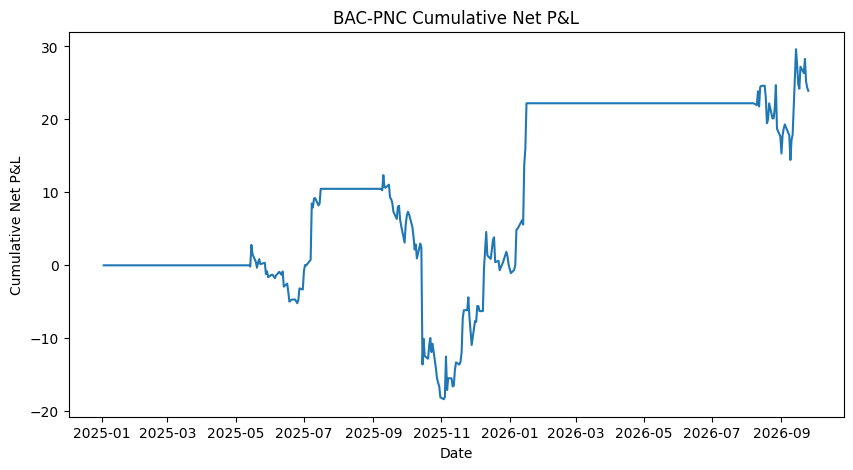

In [132]:
cumulative_net_pnl=net_pnl.cumsum()
plt.figure(figsize=(10,5))
plt.plot(cumulative_net_pnl)
plt.title("BAC-PNC Cumulative Net P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative Net P&L")
plt.show()

In [133]:
strategy_return=(net_pnl/gross_exposure.shift(1)).dropna()
sharpe=strategy_return.mean()/strategy_return.std()*np.sqrt(252)
cumulative_return=(1+strategy_return).cumprod()-1
print("Annualized Sharpe =",sharpe)
print("Final cumulative return =",cumulative_return.iloc[-1])

Annualized Sharpe = 0.5163405970637556
Final cumulative return = 0.05178599328199818


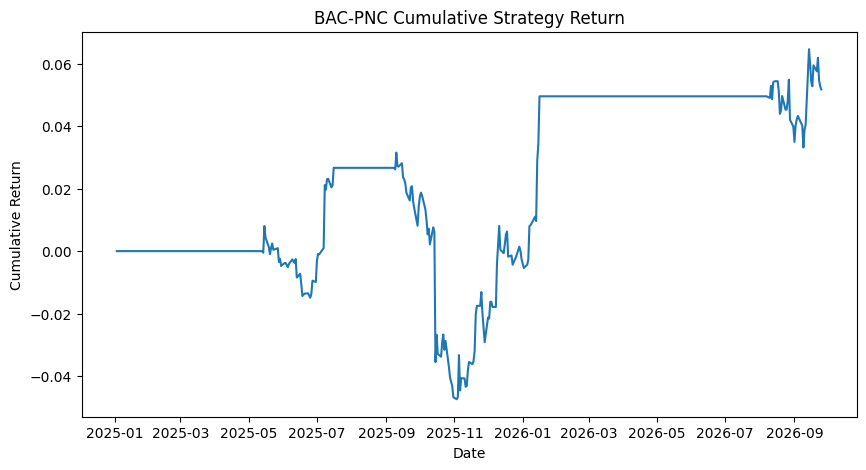

In [134]:
plt.figure(figsize=(10,5))
plt.plot(cumulative_return)
plt.title("BAC-PNC Cumulative Strategy Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.show()

## 10. Performance Summary
The strategy is evaluated using cumulative return, annualized Sharpe ratio, transaction costs, and trading activity.

In [135]:
number_of_position_changes=(position.diff().abs().fillna(0)>0).sum()
summary=pd.DataFrame({"Metric":["Train Correlation","Cointegration p-value","Hedge Ratio","Entry Threshold","Exit Threshold","Transaction Cost","Position Changes","Test Cumulative Return","Annualized Sharpe"],"Value":[0.8067,0.0406,round(beta,3),2.0,0.5,"5 bps",number_of_position_changes,f"{cumulative_return.iloc[-1]:.2%}",round(sharpe,3)]})
summary

,Metric,Value
0,Train Correlation,0.8067
1,Cointegration p-value,0.0406
2,Hedge Ratio,4.108
3,Entry Threshold,2.0
4,Exit Threshold,0.5
5,Transaction Cost,5 bps
6,Position Changes,5
7,Test Cumulative Return,5.18%
8,Annualized Sharpe,0.516


## 11. Sensitivity Analysis
To assess robustness, the strategy is re-evaluated using entry threshold of 1.5, 2.0 and 2.5 standard deviations.

A strategy that remains profitable across nearby parameter values is less likely to depend on a single arbitrary threshold.

In [136]:
def run_strategy(entry_threshold,exit_threshold=0.5):
  position=pd.Series(0,index=test_zscore.index)
  current_position=0
  for date in test_zscore.index:
    z=test_zscore.loc[date]
    if current_position==0:
      if z<-entry_threshold:
        current_position=1
      elif z>entry_threshold:
        current_position=-1
    elif current_position==1:
      if abs(z)<exit_threshold:
        current_position=0
    elif current_position==-1:
      if abs(z)<exit_threshold:
        current_position=0
    position.loc[date]=current_position
  spread_change=test_spread.diff()
  pnl=position.shift(1)*spread_change
  pnl=pnl.dropna()
  position_change=position.diff().abs().fillna(0)
  transaction_cost=position_change*gross_exposure*0.0005
  net_pnl=pnl-transaction_cost.reindex(pnl.index).fillna(0)
  strategy_return=(net_pnl/gross_exposure.shift(1)).dropna()
  sharpe=strategy_return.mean()/strategy_return.std()*np.sqrt(252)
  cumulative_return=(1+strategy_return).cumprod().iloc[-1]-1
  return sharpe,cumulative_return

In [137]:
sensitivity_results=[]
for entry in [1.5,2.0,2.5]:
  sharpe_result,cumulative_return_result=run_strategy(entry)
  sensitivity_results.append({"Entry Threshold":entry,"Sharpe":sharpe_result,"Cumulative Return":cumulative_return_result})
  sensitivity_df=pd.DataFrame(sensitivity_results)
sensitivity_df

,Entry Threshold,Sharpe,Cumulative Return
0,1.5,0.421664,0.045308
1,2.0,0.516341,0.051786
2,2.5,0.700993,0.070042


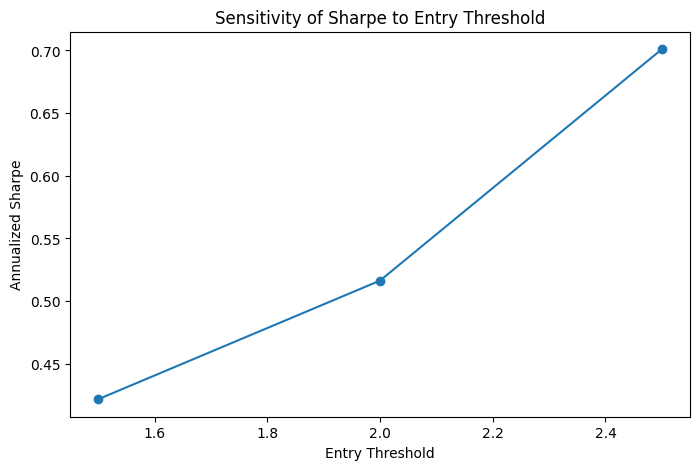

In [138]:
plt.figure(figsize=(8,5))
plt.plot(sensitivity_df["Entry Threshold"],sensitivity_df["Sharpe"],marker="o")
plt.title("Sensitivity of Sharpe to Entry Threshold")
plt.xlabel("Entry Threshold")
plt.ylabel("Annualized Sharpe")
plt.show()

## 12. Conclusion
The BAC-PNC pair showed evidence  of cointegration during the training period and produced positive out-of-sample returns under the mean-reversion strategy.

Using a 2.0 standard-deviation entry threshold, a 0.5 exit threshold, and 5 bps transaction costs, the strategy achieved approximately 5.18% cumulative return with an annualized Sharpe ratio of approximately 0.52.

Sensitivity analysis showed positive Sharpe ratios across entry thresholds of 1.5, 2.0 and 2.5, suggesting that the strategy's performance was not entirely dependent on a single entry threshold.

However, the strategy experienced meaningful drawdowns and generated only a small number of position changes, so the results should be interpreted cautiously.
### Limitations
- The stock universe is relatively small.
- The strategy uses a static hedge ratio estimated from the training period.
- The backtest contains a limited number of trades.
- Transaction costs are simplified using a constant 5 bps assumption.
- Slippage, bid-ask spreads, short-borrow costs, and financing costs are not explicitly modelled.
- Cointegration relationships may weaken or break across different market regimes.